Starting processing... (This might take a moment)
di stats: min=0.000936, max=0.058879, mean=0.030053
di_norm stats: min=0.022804, max=1.433704
new_lambda1 stats: min=0.544138, max=1.000000, mean=0.988561
div_flux stats: min=-0.365946, max=0.264001
update magnitude: 0.004089
---
di stats: min=0.000914, max=0.058874, mean=0.030141
di_norm stats: min=0.022225, max=1.432248
new_lambda1 stats: min=0.545593, max=1.000000, mean=0.988522
div_flux stats: min=-0.333743, max=0.254693
update magnitude: 0.003746
---


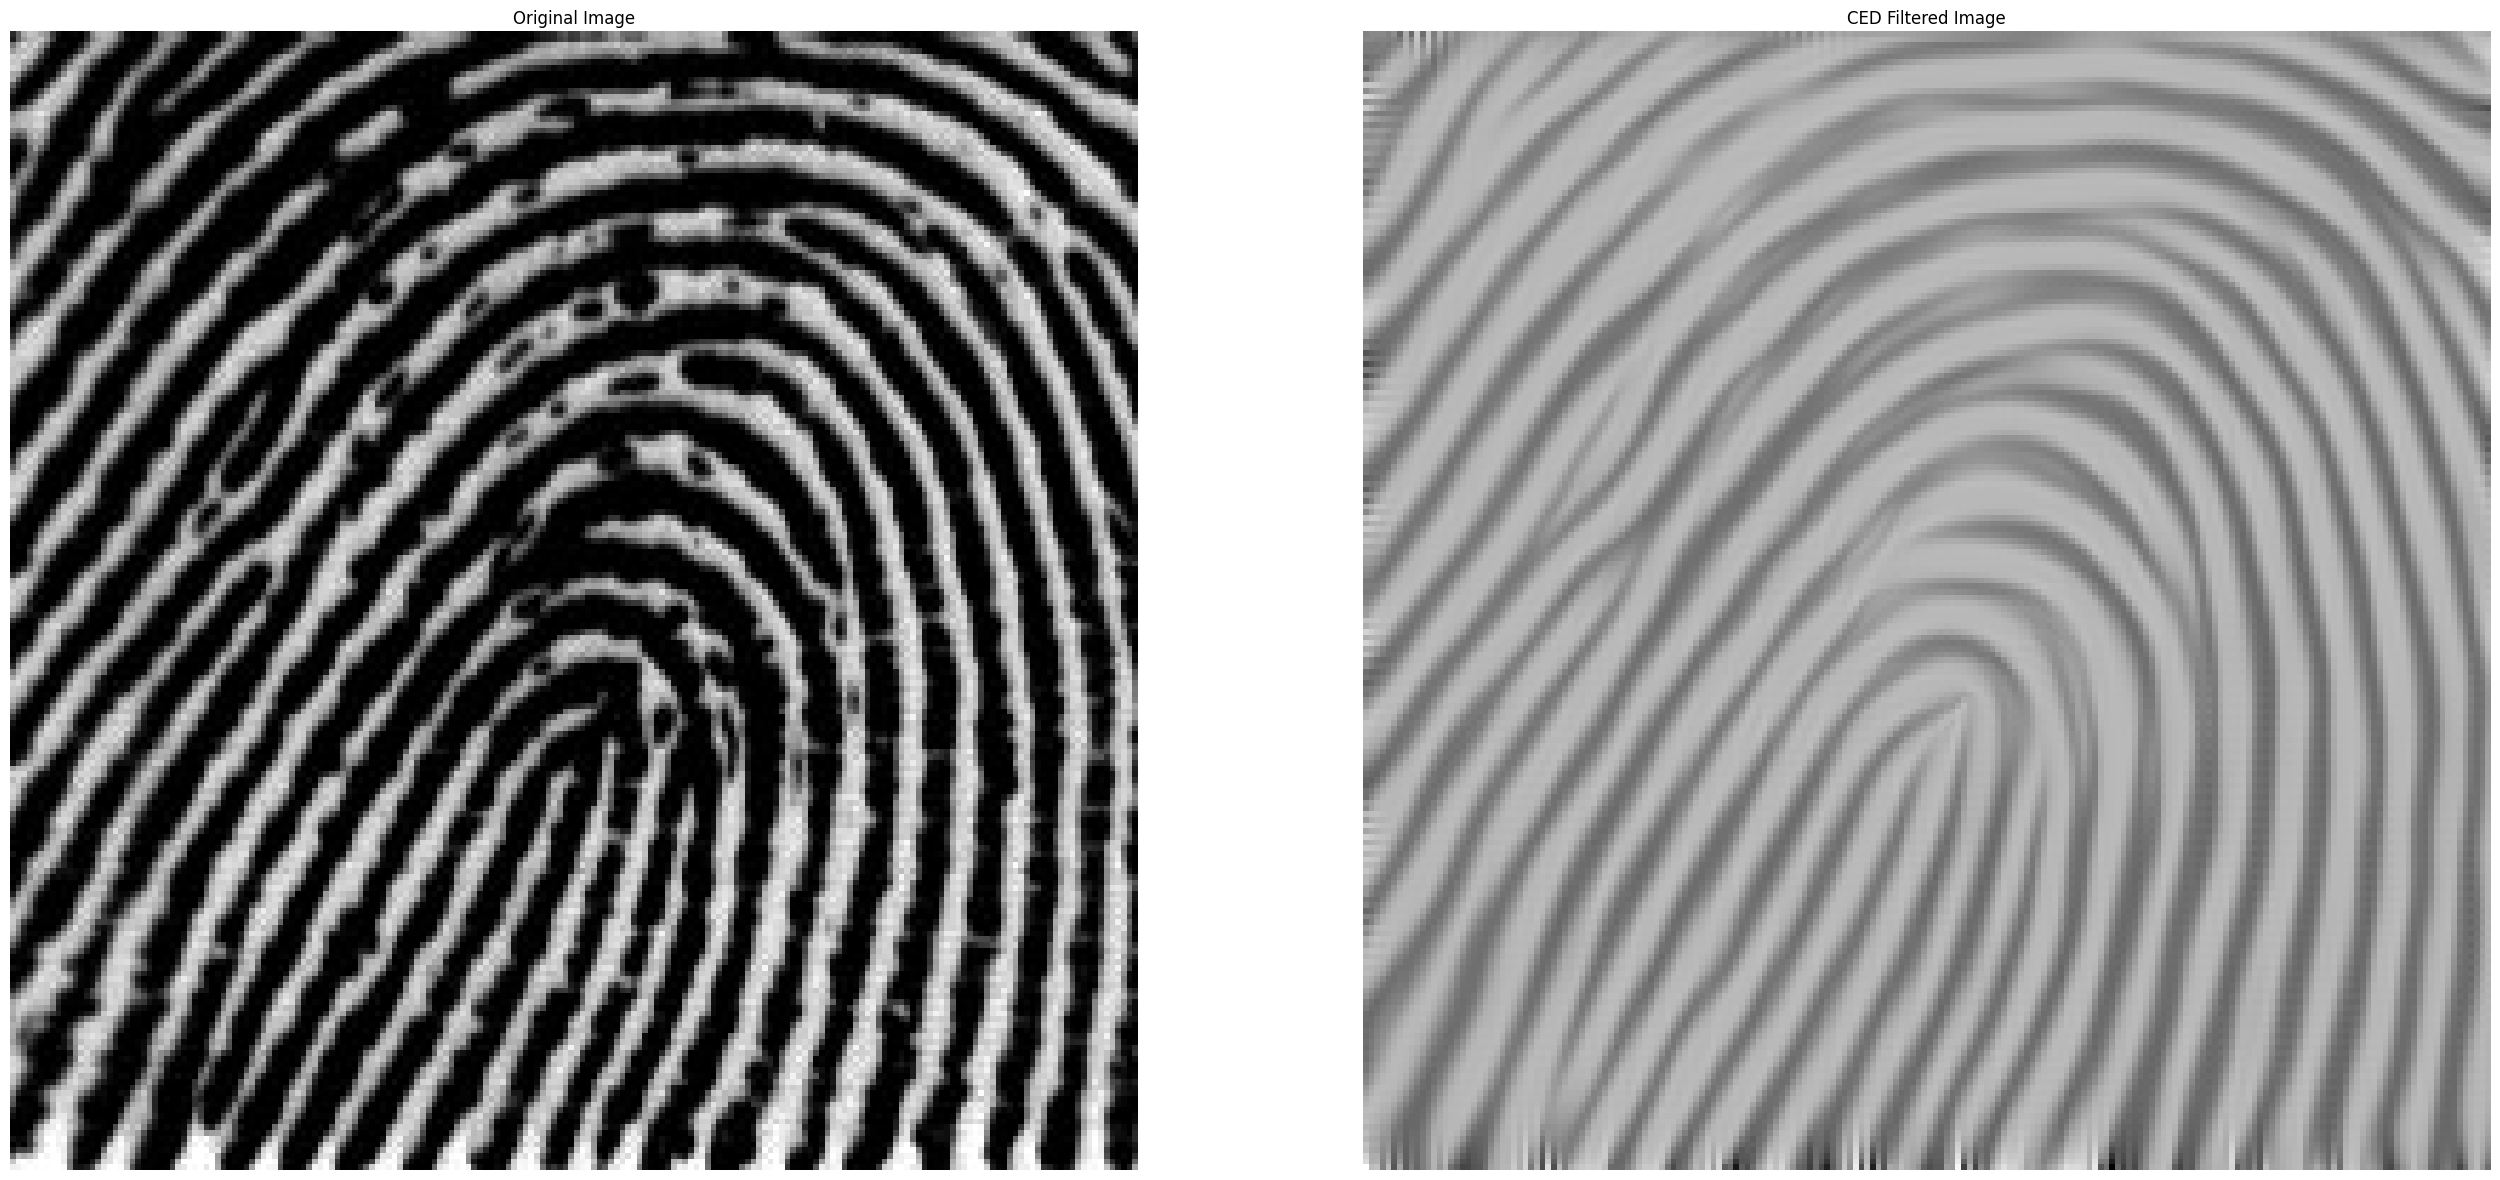

In [1]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

def coherence_enhancing_diffusion(img, T=15, sigma=0.5, rho=4.0, alpha=0.001, C=1, step_t=0.15, debug=False):
    img = img.copy().astype(np.float32) / 255.0
    
    # 迴圈計時
    t = 0
    
    print("Starting processing... (This might take a moment)")
    
    while t < T:
        # --- Step 1: 高斯平滑 (Gaussian Smoothing) ---
        u_sigma = gaussian_filter(img, sigma=sigma)
        
        # --- Step 2: 計算梯度 (Gradients) ---
        grad_y, grad_x = np.gradient(u_sigma)
        
        # --- Step 3: 計算結構張量 (Structure Tensor Elements) ---
        jxx = gaussian_filter(grad_x**2, sigma=rho)
        jxy = gaussian_filter(grad_x * grad_y, sigma=rho)
        jyy = gaussian_filter(grad_y**2, sigma=rho)
        
        # --- Step 4: 特徵值分析 (Eigen Analysis) ---
        tmp = np.sqrt((jxx - jyy)**2 + 4 * jxy**2)
        lambda1 = 0.5 * (jxx + jyy + tmp)
        lambda2 = 0.5 * (jxx + jyy - tmp)
        
        # 計算特徵向量
        angle = 0.5 * np.arctan2(2*jxy, jxx - jyy)
        v2x = np.cos(angle)
        v2y = np.sin(angle)
        v1x = -v2y
        v1y = v2x
        
        # --- Step 5: 計算擴散張量 (Diffusion Tensor) ---
        # di: Coherence (結構強度)
        di = lambda1 - lambda2
        
        # Debug: 輸出 di 的統計資訊
        if debug and t < step_t * 2:
            print(f"di stats: min={di.min():.6f}, max={di.max():.6f}, mean={di.mean():.6f}")
        
        # Weickert 公式 - 正規化 di
        # 用 di 的某個百分位數來正規化，避免數值過小
        di_norm = di / (np.percentile(di, 90) + 1e-10)
        
        if debug and t < step_t * 2:
            print(f"di_norm stats: min={di_norm.min():.6f}, max={di_norm.max():.6f}")
        
        # 沿著紋路的擴散係數
        # di_norm 大 → exp 項小 → new_lambda1 大 → 強擴散
        new_lambda1 = np.where(
            di_norm > 1e-10,
            alpha + (1 - alpha) * (1 - np.exp(-3.31488 / (di_norm**4 + 1e-10))),
            alpha
        )
        new_lambda2 = alpha
        
        if debug and t < step_t * 2:
            print(f"new_lambda1 stats: min={new_lambda1.min():.6f}, max={new_lambda1.max():.6f}, mean={new_lambda1.mean():.6f}")
        
        # 建構擴散矩陣 D 的分量
        Dxx = new_lambda1 * v1x**2 + new_lambda2 * v2x**2
        Dxy = new_lambda1 * v1x * v1y + new_lambda2 * v2x * v2y
        Dyy = new_lambda1 * v1y**2 + new_lambda2 * v2y**2
        
        # --- Step 6: 數值更新 ---
        iy, ix = np.gradient(img)
        
        flux_x = Dxx * ix + Dxy * iy
        flux_y = Dxy * ix + Dyy * iy
        
        div_flux = np.gradient(flux_x, axis=1) + np.gradient(flux_y, axis=0)
        
        if debug and t < step_t * 2:
            print(f"div_flux stats: min={div_flux.min():.6f}, max={div_flux.max():.6f}")
            print(f"update magnitude: {(step_t * div_flux).std():.6f}")
            print("---")
        
        img = img + step_t * div_flux
        t += step_t

    return img

input_image = 255 - np.array(Image.open('./1.png').convert('L'))
ced_result = 255 - coherence_enhancing_diffusion(input_image, T=20, rho=4, alpha=0.001, C=1, step_t=0.1, sigma=0.5, debug=True)
_, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(input_image, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Original Image')
ax[1].imshow(ced_result, cmap='gray')
ax[1].axis('off')
ax[1].set_title('CED Filtered Image')
plt.show()